### Here comes an outline of what this code goes through:

The scope of the code is to solve for the optimal job search effort for people who have recently lost their job and are now on unemployment benefits. 

To do that we need to know what the value of being employed and unemployed is. The value of being unemployed and employed depends on the amount of assets that one holds and the reference income that the person has in the current period. Ones the value of being employed and unemployed in every period and for every asset level is found we can compute the maximal search effort in each period and for all asset levels. 

The optimal search effort is then used to compute the 'hazard rates' (meaning the rate of exit from unemployment benefits). Finally, we have to check how vulnerable our estimated hazard rates are to different assumptions and different benefit levels. 

#### 1. We find the steady state value of being either employed or unemployed by using value function iterations. 
#### 2. We create the income path and the reference income path
The agent uses the average of the last N periods to calculate its reference. 
#### 3. We use the reference path and the steady state value of employment to find the full value of employment in every period and for every asset level. 
We do that through backwards induction for the N periods of reference until the reference level is completely adjusted to having a wage income. In the N periods we evaluate at the gain level of the utility function.n
#### 4. We write up the search cost function

#### 5. We use the search cost function to backwards iterate to the optimal consumption level and search effort for all asset levels and for every period. 

------------------------------------------------------------------------------------------------

Now I haven't gotten any further, but what we have to do is: 
1. find the inverse of the optimal search cost function
2. Use that in combination with the relative values of employment and unemployment to find the hazard rates. 

------------------------------------------------------------------------------------------------

In [364]:
import numpy as np
from time import process_time
import matplotlib.pyplot as plt
from scipy import interpolate  # Interpolation routines

#### 1. We find the SS values of employment and unemployment

It is a cake eating problem in the infinite horizon where the remaining cake grows with a given rate and an absolute factor too. 
$A' = (1+R)(A+w-c)$

And the the bellman equation is: 
$V(A) = max_{c \in A+w} ln (c) + \delta   V [(1+R)(A+w-c)]  $ \\

We can substitute $c = w + A + A' / (1+R) $ to get: \\

$V(A) = max_{0 \le A' \le A+w} ln (w + A + A' / (1+R)) + \delta   V ( A' )  $

Which is a problem solely with A, that is given and A´ which is the optimizing factor. 

In [365]:
# we determine the values such that they are only determined here and then we won't mess them up
delta = 0.95
gamma = 0.4
eta = 1
k = 130 
lmbda = 0.6

n_a = 50
n_c = 100
abar = [0,20]

T1 = 12
T2 = 36 
T3 = 48
T = 54
N = 5
b1 = 10
b2 = 8 
b3 = 6
welfare = 4
w = 15

R = 0.05

params = dict(
    delta=0.93, gamma=0.9, eta=1, k=300, lmbda=4.9,
    
    n_a=100, n_c=150, abar=[0,10000],

    T1=6, T2=18, T3=24, T=44, N=6,
    
    b1=222, b2=222, b3=114, welfare=90, w=675, R=0.01
)

# params welfare is only to be used for the value function iterations of the infinite horizon case, because then we don't have to alter the code. 
params_welfare = dict(
    delta=0.93, gamma=0.9, eta=1, k=300, lmbda=4.9,
    
    n_a=100, n_c=150, abar=[0,10000],
    
    T1=6, T2=18, T3=24, T=44, N=6,
    
    b1=222, b2=222, b3=114, welfare=90, w=222, R=0.01
)


In [366]:
class ss_value:
    """Class to implement the stochastic cake eating model with discretized choice"""

    def __init__(self, delta=0.9, abar=[0, 20], n_a=50, n_c=100, w=15, R = 0.05 ):
        """Initializer"""
        self.delta = delta    # Discount factor
        self.abar = abar    # min and max savings
        self.n_a = n_a      # grid size for state variable
        self.n_c = n_c      # grid size for choice grid
        self.w = w          # wage
        self.R = R          # interest rate

        self.abar[0] = np.maximum(np.finfo(float).eps, self.abar[0])       # vælger den højeste værdi af minimumsværdien for abar og 'numerisk 0'. Vi vil ikke under numerisk 0.  
        # truncate lower bound at smallest positive float number
        # parameter dependent varibles
        self.a = np.linspace(self.abar[0], self.abar[1], n_a).reshape((n_a, 1))  # vi laver en vektor med state space fra 0 til abar og med det antal grid punkter vi vil have, n_a.  
        self.c = np.empty((n_a, n_c))  # starter consumption matrix med rækker for alle states og så et finere grid i kolonnerne for mulige consumption valg. 
        
        for i in range(n_a):            # fordi rækkerne er state-grids, så derfor skal vi have en række for hver state vi vil kigge på
            self.c[i, :] = np.linspace(self.abar[0], self.a[i]+self.w, n_c).reshape((1, n_c))  # vi laver hver række så den går fra '0' til den værdi i state grid, som vi kigger på. Altså, det vil svare til at vi kigger på alle mulige værdier for V(A=10)
                                                                                        # consumption choice bliver så lidt finere (det er kolonnerne her) og tager n_c grid points. 
                                                                                        # så hver række repræsenterer alle consumption choices givet en state value. 


        """Bellman operator, V0 is one-dim vector of values on state grid"""
    def bellman(self, V0, R):
        interp = interpolate.interp1d(self.a[:, 0], V0, bounds_error=False, fill_value="extrapolate")
        V = 0
        a1 = (self.a - self.c + self.w)*(1+R)       # vi laver a1 som funktion af hvad du forbruger     'a' er en 1 x n_a vektor
        V = interp(a1)                              # a1 bliver en n_a x n_c matrix     V svarer til de 100 forskellige niveauer af nytte i næste periode
                                                    # a1 er en funktion af c (de andre er faste), så får vi en værdi som ligger mellem grid points ved at interpolere.
                                                    # der er ikke noget med nytte. Er det med vilje fordi den endelige værdi af V altid være den som maksimerer nytten?
        matV1 = np.log(self.c) + self.delta * V      # c er en n_a x n_c vektor   a er en na x 1 vektor a1 bliver så en n_a x n_c matrix. Det gør V så også 
                                                    # så her lægges en n_a x n_c matrix til en n_a x n_c matrix, hvilket giver en n_a x n_c matrix.
        i_max = np.argmax(matV1, axis=1)            # vi kigger på den kolonne som giver den højeste nytte for hver række. n_a x 1 matrix
        # (column) index of optimal choices
        V1 = matV1[np.arange(self.n_a), i_max]          # Her går den igennem alle n_a rækker, og finder den kolonne i hver række, som giver den højeste værdi. 
        c1 = self.c[np.arange(self.n_a), i_max]         # den her viser, hvad det optimale forbrug så viste sig at være. 

        return V1, c1
    

Adding the value function iteration solver of the Bellman equation to the class. 

In [367]:
def vfi(self, maxiter=1000, tol=1e-15, callback=None):
    """Solves the model using VFI (successive approximations)"""
    tic = process_time()  # Start the stopwatch / counter

    V0 = np.log(self.a[:, 0])  # on first iteration assume consuming everything
    
    for iter in range(maxiter):
        V1, c1 = self.bellman(V0, self.R)
        if callback:
            callback(iter, self.a, V1, c1)  # callback for making plots
        if np.all(abs(V1 - V0) < tol):
            toc = process_time()  # Stop the stopwatch / counter
            print("Optimal consumption of assets solved in", iter, "iterations, using", round(toc - tic, 5), "seconds")
            break
        V0 = V1
    else:  # when i went up to maxiter
        print("No convergence: maximum number of iterations achieved!")
    return V1, c1

# Add the vfi_solve method to the cake_stochastic class
ss_value.solve = vfi

Here we export the SS values and associated consumption for both employment and unemployment for every asset level. 
It is the same code. The only difference is the wage in the final period, which is either a wage for a job or the welfare level of income. 

In [368]:
# typing in the needed keys for the dictionary. Then we can use those and it will always match the ones defined in the dictionary. 
ss_value_keys = ['delta', 'abar', 'n_a', 'n_c', 'w', 'R']

ss_value_emp = ss_value (**{key: params[key] for key in ss_value_keys} )
Vss_emp, css_emp = ss_value_emp.solve()

ss_value_uemp = ss_value (**{key: params_welfare[key] for key in ss_value_keys} )
Vss_uemp, css_uemp = ss_value_uemp.solve() 

Optimal consumption of assets solved in 489 iterations, using 0.13207 seconds
Optimal consumption of assets solved in 494 iterations, using 0.12977 seconds


Here the value function and the consumption for both being employed and unemployed for every asset level in steady state is plotted against each other 
- we can experiment with the plots a little bit. 

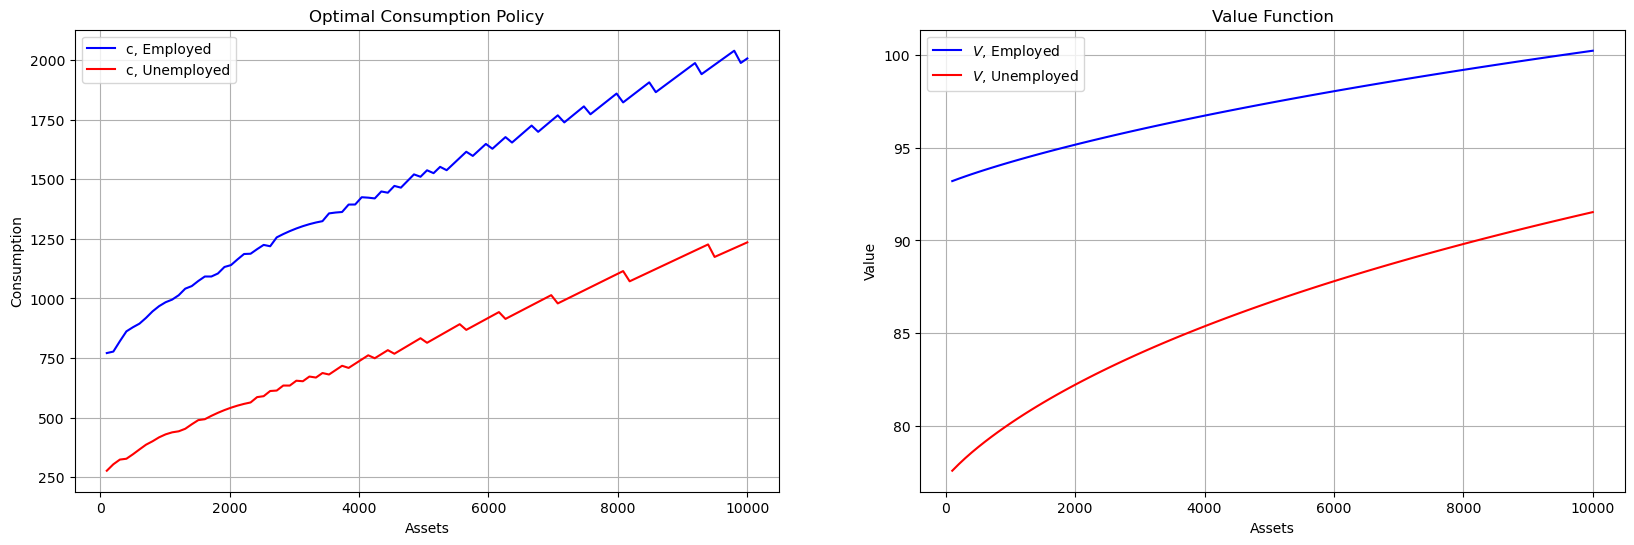

In [369]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
ax1.grid(True)
ax2.grid(True)

ax1.plot(ss_value_emp.a[1:, 0], css_emp[1:], color="b", label="c, Employed")
ax1.plot(ss_value_uemp.a[1:, 0], css_uemp[1:], color="r", label="c, Unemployed")
ax1.set_xlabel("Assets")
ax1.set_ylabel("Consumption")
ax1.legend()
ax1.set_title("Optimal Consumption Policy")

ax2.plot(ss_value_emp.a[1:, 0], Vss_emp[1:], color="b", label="$V$, Employed")
ax2.plot(ss_value_uemp.a[1:, 0], Vss_uemp[1:], color="r", label="$V$, Unemployed")
ax2.legend()
ax2.set_title("Value Function")
ax2.set_xlabel("Assets")
ax2.set_ylabel("Value")

plt.show()

Consumption burde jo ikke variere på den måde, men i stedet være roligt voksende funktioner. 

------------------------------------------------------------------------------------------------------------------------------------------------


#### 2. We find the income path and through that the reference path for getting a job in every period



In [370]:
class ref_inc_path():
    def __init__(self,w =15, b1=10, b2 = 8, b3 = 6, welfare = 4, T1 = 12, T2 = 36, T3 = 48, T = 54, N = 5, eta = 1 ):
        self.w = w              # Løn
        self.b1 = b1            # højeste dagpengesats    
        self.b2 = b2            # næste dagepengesats
        self.b3 = b3            # laveste dagpengesats
        self.welfare = welfare  # 'kontanthjælp'
        self.T1 = T1            # periode til højeste dagpengesats
        self.T2 = T2            # periode til næste dagpengesats
        self.T3 = T3            # periode til laveste dagpengesats
        self.T = T              # periode til kontanthjælp
        self.N = N              # antal referenceperioder
        self.eta = eta          # det er for at kunne modificere løsningen til også at være ikke reference-dependent

    def benefit_path_(self):                # vi laver income paths som en T, array med alle income levels for forskellige perioder
        '''
        Returns the benefit path given parameter values.
            Arguments:
                b1,b2,b3,welfare (all floats): values at distinct time windows during unemployment
                T1,T2,T3 (int): points in Unemp. spell when benefit levels change.
                T (int): Total number of periods
            Returns:
                benefits (array): Benefit path in unemployment
        '''
        benefits        = np.zeros(self.T)       # Laver en vektor med T, elementer. 
        benefits[0:self.T1]  = self.b1                # for de rigtige tidspunkter tilføjer den benefit levels. 
        benefits[self.T1:self.T2] = self.b2
        benefits[self.T2:self.T3] = self.b3
        benefits[self.T3:self.T]  = self.welfare

        return benefits
    
    def income_path_(self):                          
        '''Laver alle de mulige income paths. 
            En for alle tidspunkter hvorpå man finder et job, inklusiv muligheden for aldrig at finde et job
        '''
        benefits = self.benefit_path_()
        income_path = np.tile(benefits,(self.T+1,1))
        for j in np.arange(self.T): 
            income_path[j,j:] = self.w
        return income_path
    
    def ref_path_(self):             # the reference point is given as the arithmetic average of the income in the 5 periods leading up to the current one. 
        if self.eta > 0: 
            ref_path = np.zeros((self.T+1, self.T))
            income_path = self.income_path_()
        
            for t in np.arange(self.T): 
                if t == 0:
                    ref_path[:,t] = self.w         # vi antager at lønnen før og lønnen efter bistand er den samme. 

                if t > 0: 
                    N_pre = max(self.N - t, 0)  # vi sætter antal perioder med løn til at blive mindre, når man har været længere tid på DP. Indtil løn slet ikke indgår i referencen. 
                    '''Her modificerer jeg koden ned i kompleksitet, så vi ikke tager højde for eventuelle halve perioder. 
                    Da vi slet ikke har dem med. Se rdmodel.py, for den komplekse udgave'''
                    start = max(t-self.N, 0)
                    end = t
                        #Her laver vi summen / gennemsnittet. 
                        #Når t > 4 så betyder N_pre leddet ikke længere noget.
                    ref_path[:,t] = ( N_pre*self.w + np.sum(income_path[:,start:end], axis = 1, keepdims=False ) ) / self.N
            
                    # reference path tager gennemsnittet for de seneste fem perioder af indkomst for alle rækker i income path.
                    # så altid summen af de t-5 til t søjler i income path plus evt. led fra før dagpenge, hvis vi er i t < 5
                    # axis = 1 betyder at vi kigger på søjler keepdims = False betyder at vi kun returner en vektor med t værdier pr. række.
                    # så hver række i income path repræsenterer, hvornår man får job. Hver række i r repræsenterer den dertilhørende lønreference i alle perioder. 
        else: 
            ref_path = self.income_path_()    
            
        return ref_path
         
        
    def ref_path_long_(self):        # we create this to get the future values of ref-dependence when getting a job inside T-N last periods.
            
        add = np.zeros( (self.T+1, self.N)  )

        ref_path = self.ref_path_()
        ref_path_long = np.concatenate((ref_path, add), axis = 1)      # now we add N columns to the ref_path_
            
        income_path = self.income_path_()       # we add the income path to use it later

        for t in np.arange(self.T, self.T + self.N):
                
            start = min ( t - self.N , self.T)      # vi definerer start som den periode vi er i og minus de N perioder vi kigger tilbage. Vi går indtil sidste periode i income_path
            end = self.T                            # det her er måske overflødigt, fordi vi bare siger, at vi stopper ved enden. 

            ref_path_long[:,t] = (  np.sum(income_path[:,start:], axis = 1, keepdims=False     )   + (t-self.T)* self.w ) / self.N 
                                        # so what the code does is that it takes the sum of the last periods available in the income path
                                        # plus the sum of the periods not available and divides by N to get the average.                                  
        """ændrer den sidste række til blot at være den samme som den var før men 5 perioder mere, fordi han aldrig får et job. """
        
        ref_path_long[-1,self.T] = self.welfare
        return ref_path_long
               

In [371]:
ref_inc_path_keys = ['w', 'b1', 'b2', 'b3', 'welfare', 'T1', 'T2', 'T3', 'T', 'N', 'eta']

ref_inc_path_model = ref_inc_path(**{key: params[key] for key in ref_inc_path_keys} )
ref_path_long = ref_inc_path_model.ref_path_long_()
benefits = ref_inc_path_model.benefit_path_()
print(benefits)

#print(ref_path_long[54,50:])        # this is getting the job in period T + 1 that's why it doesn't converge. 
#print(ref_path_long.shape)


[222. 222. 222. 222. 222. 222. 222. 222. 222. 222. 222. 222. 222. 222.
 222. 222. 222. 222. 114. 114. 114. 114. 114. 114.  90.  90.  90.  90.
  90.  90.  90.  90.  90.  90.  90.  90.  90.  90.  90.  90.  90.  90.
  90.  90.]


------------------------------------------------------------------------------------------------------------------------------------------------

#### 3. We find the full value of getting a job for every asset level in every period

We solve the following maximization problem for every asset level in every period

$   V(A_t) = max _{0 \le A_{t+1} \le A_t } u \left(w+A_t + \frac{A_{t+1}}{1+R} \right) + \eta \left( u[w+A_t + \frac{A_{t+1}}{1+R}] - u[r_t]  \right)  + V(A_{t+1})    $ 




We call the steady state value function that we have already made in step 1

In [372]:
def employment_BI(Vss, ref_path, delta, eta, R, w, abar, T, N, n_a, n_c):
    abar[0] = np.maximum(np.finfo(float).eps, abar[0])              # vælger numerisk nul, så vi kan tage log. 
    a = np.linspace(abar[0], abar[1], n_a).reshape((n_a, 1))        # laver en n_a x 1 matrice med værdierne fra 0 til maks asset level. 

    c = np.empty((n_a, n_c))    # For hver state kan man vælge n_c forskellige niveauer af forbrug i perioden
    for i in range(n_a):        # vi kigger på alle rækkerne og tilføjer forbrugsmuligheder fra 0 og op til maks forbrug som er givet ved assets + løn.  
        c[i, :] = np.linspace(abar[0], (a[i]+w), n_c).reshape((1, n_c))     # Laver det om til en vektor med 1 række og n_c kolonner. 

    a1 = (a - c + w) * (1 + R)   # assets i næste periode. Det er en n_a x n_c matrix. 

    V_emp = np.zeros((T+1, n_a))   # placeholder variable for getting the job in period in period T with asset value a. 
    c_emp = np.zeros((T+1, n_a))   # associated optimal consumption, first period after job start, not really that relevant though...

    for j in np.arange(T+1):
        V0 = Vss   # steady state value from the value function iterations. 

        # step backward: n = N-1 (period closest to steady state) down to n = 0 (period job starts)
        for n in np.arange(N-1, -1, -1):
            interp = interpolate.interp1d(a[:, 0], V0, bounds_error=False, fill_value="extrapolate")    # here it always takes the latest V0 value, so a new one in every period. This is where the updated values get used. 
            V_next = interp(a1)     # V_next er jo altid den seneste værdi. Første del af loopet er så den 'interpolerede' værdi fra v_ss af givne asset levels mellem grids. 

            matV1 = np.log(c) + eta * (np.log(c) - np.log(ref_path[j, j+n])) + delta * V_next    # nytteværdi for givet 'j' jobtidspunkt for n-perioder efter job er fundet. 
                                                            # og så fordi at c er defineret som alle forbrugsmuligheder med forskellige asset levels overholdet det budget begrænsningen. 
            i_max = np.argmax(matV1, axis=1)                # hvordan overholder vi budgetbegrænsningen i næste periode? 
            V0 = matV1[np.arange(n_a), i_max]               # her opdateres værdierne givet det optimale forbrugsval. Det bliver så genbrugt til næste periode. 
            c_current = c[np.arange(n_a), i_max]

        V_emp[j, :] = V0
        c_emp[j, :] = c_current

    V_emp = V_emp.transpose( )
    c_emp = c_emp.transpose()
    return V_emp, c_emp

Her får vi værdierne. c_out er lidt ligemeget, fordi det er den endelige c-værdi, hvilket vi egentlig ikke skal bruge. Altså, vi tracker slet ikke på den her måde den rigtige consumption path, men kun den sidste værdi. Vi skal heller ikke rigtigt bruge den, men hvis vi vil, så har claude lavet et udkast til kode for det, som ligger i VFI asset. 

We output the values of employment for every period and every asset level.

Vi kan lave en graf, som viser udviklingen i asset levels, for alle de forskellige initiale niveauer af assets. 
Men det kan man så også gøre for alle tidsperioder. 

In [373]:
employment_BI_keys = [ 'delta', 'eta', 'R', 'w', 'abar', 'T', 'N', 'n_a', 'n_c']
# here we also need to reference the ref path and the ss value from earlier functions, and they can't be defined inside the param keys. 
# But they will be updated when we change the keys in the beginning
V_emp, c_emp = employment_BI(**{key: params[key] for key in employment_BI_keys}, ref_path = ref_path_long, Vss = Vss_emp )

#print(V_emp[49,:])      # rækkerne er asset levels
                        # kollerne er tidspunkter at få jobbet på
                        
#print(V_emp[:,54])       # vi kan også se det ved det her print, hvor nogle af værdierne er ens fordi personerne når at tilpasse sig de nye lavere niveauer af indkomst. 
                        
# vi kan også bare se det ved at kigge på shape, hvor der er 50 asset levels og 54+1 tidsperioder. 
print(V_emp.shape)

(100, 45)


------------------------------------------------------------------------------------------------------------------------------------------------

#### 4. We write up the search cost function.

The optimal search effort is found through the FOC of the value function for unemployment wrt. s. This leaves us with a function showing the marginal change in the optimal search effort for changes in the asset levels. 

$
\text{FOC:} \frac{\partial V^U_t(A_t)}{\partial s_t}=0 \\
    \leftrightarrow 
    c'(s_t^*(A_{t+1}) = \delta [V^E_{t+1|t+1}(A_{t+1})-V^U_{t+1}(A_{t+1})] 
$

Here the sanity check is that the marginal search effort should be decreasing in A. Which it does because we have diminishing marginal return to income and since the income level when unemployed is lowest then: 

$V^U (A+1) - V^U(A) > V^E(A+1)-V^E(A) $

From the first order condition we can isolate s by taken the inverse of the derivative of the search cost function. 

$c_s = \frac{ks^{1+\gamma}}{1+\gamma}$ then $c'_s = ks^\gamma$ and the inverse is given by: 

$c'(s) = ks^\gamma \\
 \leftrightarrow s = \left( \frac{c'}{k} \right)^{1/\gamma } = 
 c'^{-1}(\cdot) =
\mathcal{C}(\cdot)    $ 

So we must 

$s^*_t = \mathcal{C}(\delta [V^E_{t+1|t+1}(A_{t+1})-V^U_{t+1}(A_{t+1})]) = \left( \frac{\delta }{k} [V^E_{t+1|t+1}(A_{t+1})-V^U_{t+1}(A_{t+1})] \right)^{1/\gamma}$ 




In [374]:
# Search Cost: here arguments are scale parameter (k), level of search effort (s) and curvature parameter (gamma)
def s_cost(s,k,gamma):
    '''
    Returns the value of the search cost function.
        Arguments:
            s (float): Search effort
            k (float): Constant parameter in the search cost function
            gamma (float): Shape/elasticity parameter in the search cost function.
        Returns:
            cost(args) (float): Value of the search cost function.
    '''
    return k*s**(1+gamma)/(1+gamma)


In [375]:
def best_search(V_emp,V_uemp,k,gamma,delta):
    '''
    Returns the value of the inverse of the first derivative of the search cost function.
        Arguments:
            k (float): Scaling parameter in the search cost function
            gamma (float): Shape/elasticity parameter in the search cost function.
            delta (float): Intertemporal discount factor
            valSearch (float): Net value of job search while unemployed
        Returns:
            search (float): Value of the inverse of the first derivative of the search cost function.
    '''
    # Since s is a probability and within [0,1], we set boundaries at 0 and 1, to make sure, it does not return a value outside this interval
    search = np.minimum(1,np.maximum(delta/k*(V_emp-V_uemp),0))**(1/gamma)
    # search = 0
    return search

------------------------------------------------------------------------------------------------------------------------------------------------

#### 5. We use the search cost function to backwards iterate to the optimal consumption level and search effort for all asset levels and for every period.

We do that through approximately the same function, but adjusted to being in the 'loss' section of the gain-loss part of the value function and adjusted to the decreasing income throughout the benefit path. 

I 'def_solve_single_type_models' i koden fra harvard, så har de det, men bare ikke får asset levels. Så det er grundlæggende 'blot' at udvide med hvert asset level. Alle de nødvendige komponenter har vi allerede lavet nu. 

Det er den nedenstående her som du arbejder på. Den må du ikke slette. 

In [395]:
# Vi finder værdien af ikke at have et arbejde i hver periode
# Vi skal bruge SS værdierne, som skal opdateres løbende, fordi vi også kigger i hver periode. 
# vi skal bruge den eksogent givne optimal search effort. 
# Den skal vi bruge til at udregne search cost og ssh for at få et job i næste periode. 
# vi skal bruge ref path til hele tiden at finde værdien af indkomsten for unemployment. Vi skal også bruge gain-loss parameter funktionen vel? 

class value_uemp():
    def __init__(self, Vss_uemp, css_emp, css_uemp, Ve, ref_path, delta, eta, lmbda, gamma, k, R, benefits, abar, w, T, N, n_a, n_c):
        self.Vss_uemp = Vss_uemp
        self.css_emp = css_emp
        self.css_uemp = css_uemp
        self.Ve = Ve
        self.ref_path = ref_path
        self.delta = delta
        self.eta = eta
        self.lmbda = lmbda
        self.R = R
        self.benefits = benefits
        self.abar = abar
        self.w = w
        self.T = T
        self.N = N
        self.n_a = n_a
        self.n_c = n_c
        self.gamma = gamma
        self.k = k

        """Here we define all the values that we need"""
        # grid setup, done once when the object is created
        self.abar[0] = np.maximum(np.finfo(float).eps, self.abar[0])                        # grænseværdierne for vores opsparing
        self.a = np.linspace(self.abar[0], self.abar[1], self.n_a).reshape((self.n_a, 1))  # laver en n_a x 1 matrice med værdierne fra 0 til maks asset level.

    def unemployment_BI(self):
        V_uemp = np.zeros((self.n_a, self.T+1))   # placeholder variable for getting the job in period in period T with asset value a. 
        c_uemp = np.zeros((self.n_a, self.T+1))   # associated optimal consumption, first period after job start, not really that relevant though...
        search_out = np.zeros((self.n_a, self.T+1))  # place holder for optimal search effort for every asset level and in every period. 
    
        V0 = self.Vss_uemp          # vi hiver startværdien til BI fra steady state værdien af unemployment fundet ved VFI.
        V_uemp[:,self.T] = V0       # vi kalder terminalværdien af unemployment til at være steady state værdien af unemployment.

        y = self.benefits           # vi definerer y som benefit levels

        
        c_uemp[:,self.T] = self.css_uemp        # vi definerer forbrug i sidste periode som værende forbruget fundet i VFI
        c_emp[:,self.T] = css_emp               # vi definerer forbrug i sidste periode som værende forbruget fundet i VFI

        for j in range(self.T-1,-1,-1): 

            c = np.linspace( self.abar[0], (self.a + y[j]), self.n_c).reshape((self.n_a, self.n_c))  # Vi laver forbrug, så det hele tiden tager udgangspunkt i alle asset levels og benefit i den periode. 
            
            self.a1 = (self.a - c + y[j]) * (1 + self.R)   # budgetbegrænsning
            
            search_effort = best_search(self.Ve[:,j],V0, self.k,self.gamma,self.delta)            # this is the optimal search effort given the values of employment and unemployment.
            search_cost = s_cost(search_effort, self.k, self.gamma)                     # this should be the search cost given the optimal effort.
            # Da der kun er én maks search effort, så er det en n_a x 1 vektor. Og så kører vi den 54 gange gennem loopet, hvor den tager en ny kolonne fra den originale matrice.  

            V0 = search_effort * self.Ve[:,j] + (1-search_effort) * V0   # this is the value of being unemployed in the next period, given the optimal search effort. 
                                                                                                       
            interp = interpolate.interp1d(self.a[:,0],V0, bounds_error = False, fill_value = "extrapolate")
            V_next = interp(self.a1)

            # vi laver en gain-loss nytte, som vi kan sætte ind i vores nyttefunktion, hvor gain_loss afhænger af om c relativt til r.
            gain_loss = np.where(                           # hvad er np.where helt præcist?
                c > self.ref_path[-1,j],
                self.eta * (    np.log(c) - np.log(self.ref_path[-1,j])    ),
                self.eta * self.lmbda * (    np.log(c) - np.log(self.ref_path[-1,j])    )
            )    
        
            matV1 = np.log(c) + gain_loss - search_cost[:,None] + self.delta * V_next

            i_max = np.argmax(matV1, axis = 1)
            V0 = matV1[np.arange(self.n_a), i_max]
            c_current = c[np.arange(self.n_a), i_max]
    
            V_uemp[:,j] = V0
            c_uemp[:,j] = c_current
            search_out[:,j] = search_effort
        
        return V_uemp, c_uemp, search_out, y


In [396]:
value_uemp_keys = [ 'delta', 'eta', 'lmbda', 'gamma', 'k', 'R',  'abar', 'w', 'T', 'N', 'n_a', 'n_c']

value_uemp_model = value_uemp( **{key: params[key] for key in value_uemp_keys}, Vss_uemp = Vss_uemp, css_emp = css_emp, css_uemp = css_uemp, Ve = V_emp, ref_path = ref_path_long, benefits = benefits)
V_uemp, c_uemp, search_out, y = value_uemp_model.unemployment_BI()

#print(search_out[49,54])
#print(search_out[49,:])
print(V_uemp[0,-1])
print(V_uemp[99,-1])

print(y)




77.18110545531825
91.53159620473461
[222. 222. 222. 222. 222. 222. 222. 222. 222. 222. 222. 222. 222. 222.
 222. 222. 222. 222. 114. 114. 114. 114. 114. 114.  90.  90.  90.  90.
  90.  90.  90.  90.  90.  90.  90.  90.  90.  90.  90.  90.  90.  90.
  90.  90.]


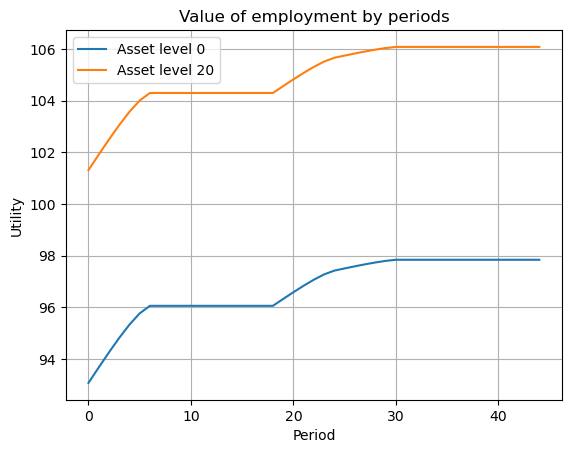

In [397]:
import matplotlib.pyplot as plt


#plt.plot(search_out.T[:,:] )
#plt.plot(search_out[20,:], label="Asset level 50")
plt.plot(V_emp[0,:], label="Asset level 0")
plt.plot(V_emp[49,:], label="Asset level 20")
plt.xlabel("Period")
plt.ylabel("Utility")
plt.title("Value of employment by periods")
plt.legend()
plt.grid(True)
plt.show()

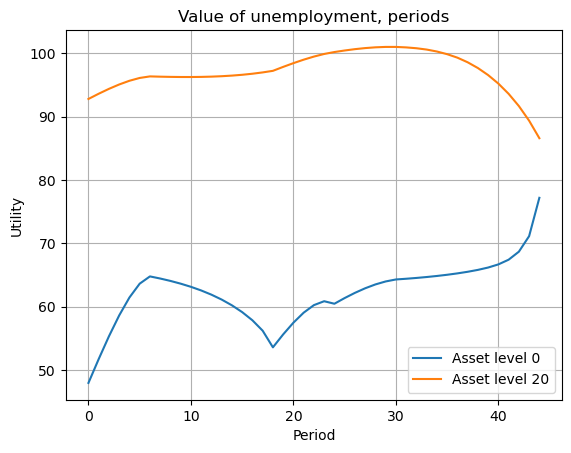

In [398]:
#plt.plot(search_out.T[:,:] )
#plt.plot(search_out[20,:], label="Asset level 50")
plt.plot(V_uemp[0,:], label="Asset level 0")
plt.plot(V_uemp[49,:], label="Asset level 20")
plt.xlabel("Period")
plt.ylabel("Utility")
plt.title("Value of unemployment, periods")
plt.legend()
plt.grid(True)
plt.show()

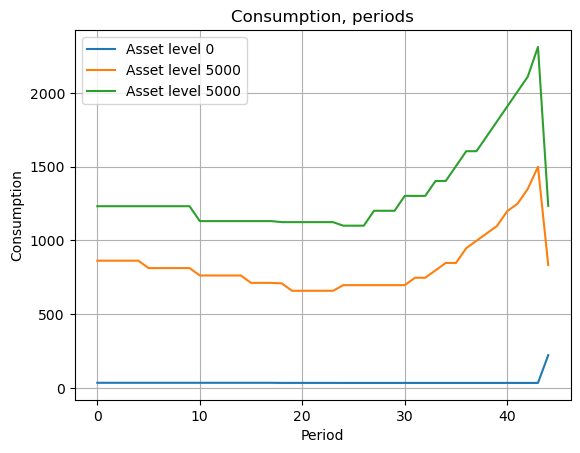

In [399]:
plt.plot(c_uemp[0,:], label="Asset level 0")
plt.plot(c_uemp[49,:], label="Asset level 5000")
plt.plot(c_uemp[99,:], label="Asset level 5000")

plt.xlabel("Period")
plt.ylabel("Consumption")
plt.title("Consumption, periods")
plt.legend()
plt.grid(True)
plt.show()

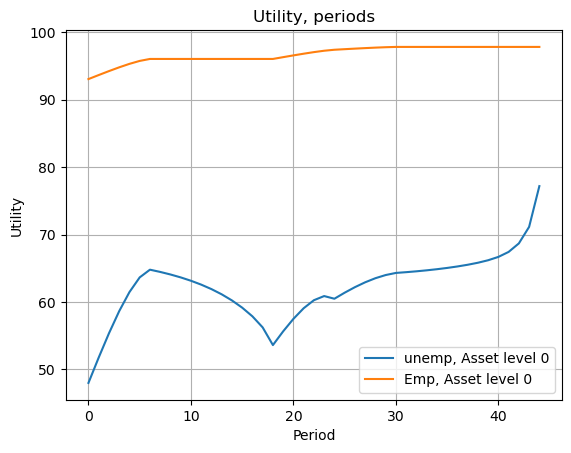

In [402]:
#plt.plot(search_out.T[:,:] )
#plt.plot(search_out[20,:], label="Asset level 50")
plt.plot(V_uemp[0,:], label="unemp, Asset level 0")#, color = 'b') 
plt.plot(V_emp[0,:], label="Emp, Asset level 0")# , color = 'b')

plt.xlabel("Period")
plt.ylabel("Utility")
plt.title("Utility, periods")
plt.legend()
plt.grid(True)
plt.show()

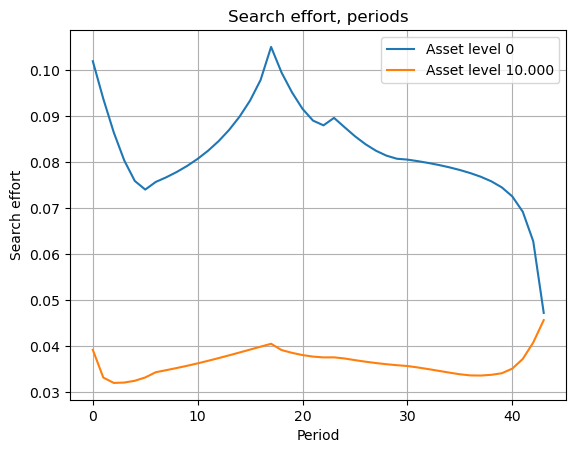

In [404]:
#plt.plot(search_out.T[:,:] )
#plt.plot(search_out[20,:], label="Asset level 50")
plt.plot(search_out[0,:-1], label="Asset level 0")
plt.plot(search_out[10,:-1], label="Asset level 10.000")
plt.xlabel("Period")
plt.ylabel("Search effort")
plt.title("Search effort, periods")
plt.legend()
plt.grid(True)
plt.show()

Koden herunder kigger efter problemer i ovenstående kode. Den skal slettes bagefter. 

In [164]:
def best_search(V_emp,V_uemp,k,gamma,delta):
    '''
    Returns the value of the inverse of the first derivative of the search cost function.
        Arguments:
            k (float): Scaling parameter in the search cost function
            gamma (float): Shape/elasticity parameter in the search cost function.
            delta (float): Intertemporal discount factor
            valSearch (float): Net value of job search while unemployed
        Returns:
            search (float): Value of the inverse of the first derivative of the search cost function.
    '''
    # Since s is a probability and within [0,1], we set boundaries at 0 and 1, to make sure, it does not return a value outside this interval
    search = np.minimum(1,np.maximum(delta/k*(V_emp-V_uemp),0))**(1/gamma)
    # search = 0
    return search

In [165]:
def search_check(V_emp,V_uemp,k,gamma,delta):
    '''
    Returns the value of the inverse of the first derivative of the search cost function.
        Arguments:
            k (float): Scaling parameter in the search cost function
            gamma (float): Shape/elasticity parameter in the search cost function.
            delta (float): Intertemporal discount factor
            valSearch (float): Net value of job search while unemployed
        Returns:
            search (float): Value of the inverse of the first derivative of the search cost function.
    '''
    # Since s is a probability and within [0,1], we set boundaries at 0 and 1, to make sure, it does not return a value outside this interval
    search = (delta/k*(V_emp-V_uemp))**(1/gamma)
    # search = 0
    return search

In [427]:
V0 = Vss_uemp
Ve = V_emp

for j in np.arange(54,-1,-1):           # Vi skal kigge på alle perioder fra 0 til endeperioden men startende i endeperioden
            search_effort = search_check(Ve[:,j],V0, 1, 0.1 ,0.95)            # this is the optimal search effort given the values of employment and unemployment.
            print(search_effort)                     # this should be the search cost given the optimal effort.
        

[3.03580567e+14 2.98872973e+14 2.94310276e+14 2.89872332e+14
 2.85544958e+14 2.81315788e+14 2.77162691e+14 2.73095025e+14
 2.69108672e+14 2.65202747e+14 2.61377743e+14 2.57605077e+14
 2.53903623e+14 2.50271178e+14 2.46710419e+14 2.43202149e+14
 2.39762101e+14 2.36366638e+14 2.33033859e+14 2.29765246e+14
 2.26552185e+14 2.23389524e+14 2.20276481e+14 2.17218071e+14
 2.14209968e+14 2.11243983e+14 2.08314736e+14 2.05439899e+14
 2.02619868e+14 1.99833809e+14 1.97097600e+14 1.94408416e+14
 1.91747483e+14 1.89142340e+14 1.86570501e+14 1.84043831e+14
 1.81545050e+14 1.79090154e+14 1.76681206e+14 1.74294849e+14
 1.71975721e+14 1.69664415e+14 1.67394684e+14 1.65162970e+14
 1.62957146e+14 1.60792063e+14 1.58662523e+14 1.56556308e+14
 1.54481606e+14 1.52460405e+14]
[3.03580567e+14 2.98872973e+14 2.94310276e+14 2.89872332e+14
 2.85544958e+14 2.81315788e+14 2.77162691e+14 2.73095025e+14
 2.69108672e+14 2.65202747e+14 2.61377743e+14 2.57605077e+14
 2.53903623e+14 2.50271178e+14 2.46710419e+14 2.43202